# Car Price Prediction — Principal Component Analysis (PCA)

**Master's in Applied Artificial Intelligence (MNA)** · Tecnológico de Monterrey
Course TC5053 — Data Science and Analytics · Week 7: Principal Component Analysis (PCA)

**Author:** Ricardo Martín Galván Páez

---

## Overview

This notebook explores the `automobile_dataset.csv` dataset (205 cars, 26 columns, UCI Machine Learning Repository) and prepares its features for a price-regression model: cleaning missing values, exploratory analysis, imputation, scaling, **PCA** on the numeric variables, and one-hot encoding of the categorical ones. The **target variable** is `price`.

| Step | Section | Technique |
|---|---|---|
| 1 | Loading and cleaning | Replace `?` with `NaN`, fix data types |
| 2 | Univariate EDA | Duplicates, missing values, descriptive statistics, histograms, bar charts |
| 3 | Bivariate EDA | Stacked bars, boxplot, top-10 prices, scatter plot |
| 4 | Correlation | Heatmap, variables most correlated with `price` |
| 5 | Feature engineering | `SimpleImputer` (mean) and `StandardScaler` |
| 6 | PCA | Projection, check that components are uncorrelated |
| 7 | Explained variance | Cumulative curve, components needed for > 90 % |
| 8 | Loadings | Contribution of each variable to the components |
| 9 | Encoding | `OneHotEncoder` with `drop='first'` |
| 10 | Final dataset | PCA + encoded variables + `price`, exported to CSV |

**Running the notebook:** it runs in Google Colab (the CSV is read from Google Drive) or locally (place the CSV at `data/automobile_dataset.csv`).

## Dataset description

The dataset gathers technical specifications of cars, collected to analyze different aspects of the vehicles and their prices: manufacturer, engine type, dimensions, weight, fuel economy and other specifications.

| Column | Description |
|---|---|
| `symboling` | Insurance risk rating, from −3 (low risk) to +3 (high risk) |
| `normalized_losses` | Normalized insurance losses (value from the insurer, sometimes missing) |
| `make` | Car make (e.g., Audi, BMW, Honda) |
| `fuel_type` | Fuel type (gas or diesel) |
| `aspiration` | Engine aspiration (standard or turbo) |
| `num_doors` | Number of doors (two or four) |
| `body_style` | Body style (sedan, hatchback, wagon, hardtop, convertible) |
| `drive_wheels` | Drive type (`fwd`: front, `rwd`: rear, `4wd`: four-wheel) |
| `engine_location` | Engine location (front or rear) |
| `wheel_base` | Wheelbase (inches) |
| `length` | Overall length (inches) |
| `width` | Overall width (inches) |
| `height` | Overall height (inches) |
| `curb_weight` | Curb weight (pounds) |
| `engine_type` | Engine type (OHV, OHC, DOHC, etc.) |
| `num_cylinders` | Number of cylinders |
| `engine_size` | Engine size (cc) |
| `fuel_system` | Fuel system (e.g., mpfi, 2bbl, 4bbl) |
| `bore` | Cylinder bore diameter (inches) |
| `stroke` | Piston stroke (inches) |
| `compression_ratio` | Engine compression ratio |
| `horsepower` | Engine power (horsepower) |
| `peak_rpm` | Peak revolutions per minute |
| `city_mpg` | City fuel economy (miles per gallon) |
| `highway_mpg` | Highway fuel economy (miles per gallon) |
| `price` | Car price (USD). **Target variable** to be predicted by the downstream model |

---

## 0. Setup

In [ ]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# Data location: Google Drive when running in Colab, ./data/ when running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/ Actividad 7 | PCA/automobile_dataset.csv"
except ImportError:
    DATA_PATH = "data/automobile_dataset.csv"  # local run: place the CSV in ./data/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

## 1. Data loading and initial cleaning

**Goals**
- Load all records into a dataframe (`cars_df`).
- Summarize the data types with `info()`: how many columns are numeric and how many are text?
- Identify the columns that contain the `?` symbol, used to flag missing values.
- Replace `?` with `NaN` and convert the columns to the right data type. While the symbol was present, pandas read these columns as `object` even though they are numeric.

In [ ]:
# Load the data
cars_df = pd.read_csv(DATA_PATH)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

**Result (before conversion):** 12 numeric columns and 14 text columns.

In [ ]:
cars_df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
# Replace the '?' symbol with missing values (NaN)
cars_df.replace('?', np.nan, inplace=True)
cars_df.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized_losses,NaN,NaN,NaN,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel_type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num_doors,two,two,two,four,four
body_style,convertible,convertible,hatchback,sedan,sedan
drive_wheels,rwd,rwd,rwd,fwd,4wd
engine_location,front,front,front,front,front
wheel_base,88.6,88.6,94.5,99.8,99.4


In [ ]:
# Convert the columns that contained '?' to numeric
cars_df['normalized_losses'] = pd.to_numeric(cars_df['normalized_losses'])
cars_df['bore'] = pd.to_numeric(cars_df['bore'])
cars_df['stroke'] = pd.to_numeric(cars_df['stroke'])
cars_df['horsepower'] = pd.to_numeric(cars_df['horsepower'])
cars_df['peak_rpm'] = pd.to_numeric(cars_df['peak_rpm'])
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

**Result:** the `?` symbol appeared in 5 columns, which are now numeric and keep their missing values:

| Column | Missing values |
|---|---|
| `normalized_losses` | 41 |
| `bore` | 4 |
| `stroke` | 4 |
| `horsepower` | 2 |
| `peak_rpm` | 2 |

After the conversion the dataframe has 17 numeric columns and 9 text columns.

---

## 2. Exploratory data analysis (univariate)

**Goals**
- Check for duplicate records and print the percentage of missing values per column.
- Compute descriptive statistics, separately for numeric variables (including skewness and kurtosis) and categorical variables (including frequency tables).
- Plot histograms for the numeric variables and bar charts for the categorical ones.

In [ ]:
cars_df.duplicated().sum()

np.int64(0)

**Percentage of missing values per column**

In [ ]:
cars_df.isna().mean()*100

,0
symboling,0.00000
normalized_losses,20.00000
make,0.00000
fuel_type,0.00000
aspiration,0.00000
num_doors,0.00000
body_style,0.00000
drive_wheels,0.00000
engine_location,0.00000
wheel_base,0.00000


**Result:** there are no duplicate records. The only missing values are in `normalized_losses` (20 %), `bore` and `stroke` (1.95 % each), and `horsepower` and `peak_rpm` (0.98 % each).

### Numeric variables: descriptive statistics, skewness and kurtosis

In [ ]:
cat_cols = cars_df.select_dtypes(include='object')
num_cols = cars_df.select_dtypes(include='number')

In [ ]:
describe_df = cars_df[num_cols.columns].describe().T
describe_df['skew'] = cars_df[num_cols.columns].skew()
describe_df['kurtosis'] = cars_df[num_cols.columns].kurtosis()
describe_df

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00,0.211072,-0.676271
normalized_losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00,0.765976,0.525440
wheel_base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90,1.050214,1.017039
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10,0.155954,-0.082895
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30,0.904003,0.702764
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80,0.063123,-0.443812
curb_weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00,0.681398,-0.042854
num_cylinders,205.0,4.380488,1.080854,2.00,4.00,4.00,4.00,12.00,2.817459,13.714866
engine_size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00,1.947655,5.305682
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94,0.020016,-0.828945


### Categorical variables: descriptive statistics and frequency tables

In [ ]:
cat_cols.describe().T

,count,unique,top,freq
make,205,22,toyota,32
fuel_type,205,2,gas,185
aspiration,205,2,std,168
num_doors,205,2,four,116
body_style,205,5,sedan,96
drive_wheels,205,3,fwd,120
engine_location,205,2,front,202
engine_type,205,7,ohc,148
fuel_system,205,8,mpfi,94


In [ ]:
for column in cat_cols:
  print(cars_df[column].value_counts())
  print('-'* 50)

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64
--------------------------------------------------
fuel_type
gas       185
diesel     20
Name: count, dtype: int64
--------------------------------------------------
aspiration
std      168
turbo     37
Name: count, dtype: int64
--------------------------------------------------
num_doors
four    116
two      89
Name: count, dtype: int64
--------------------------------------------------
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
-----------

### Distributions

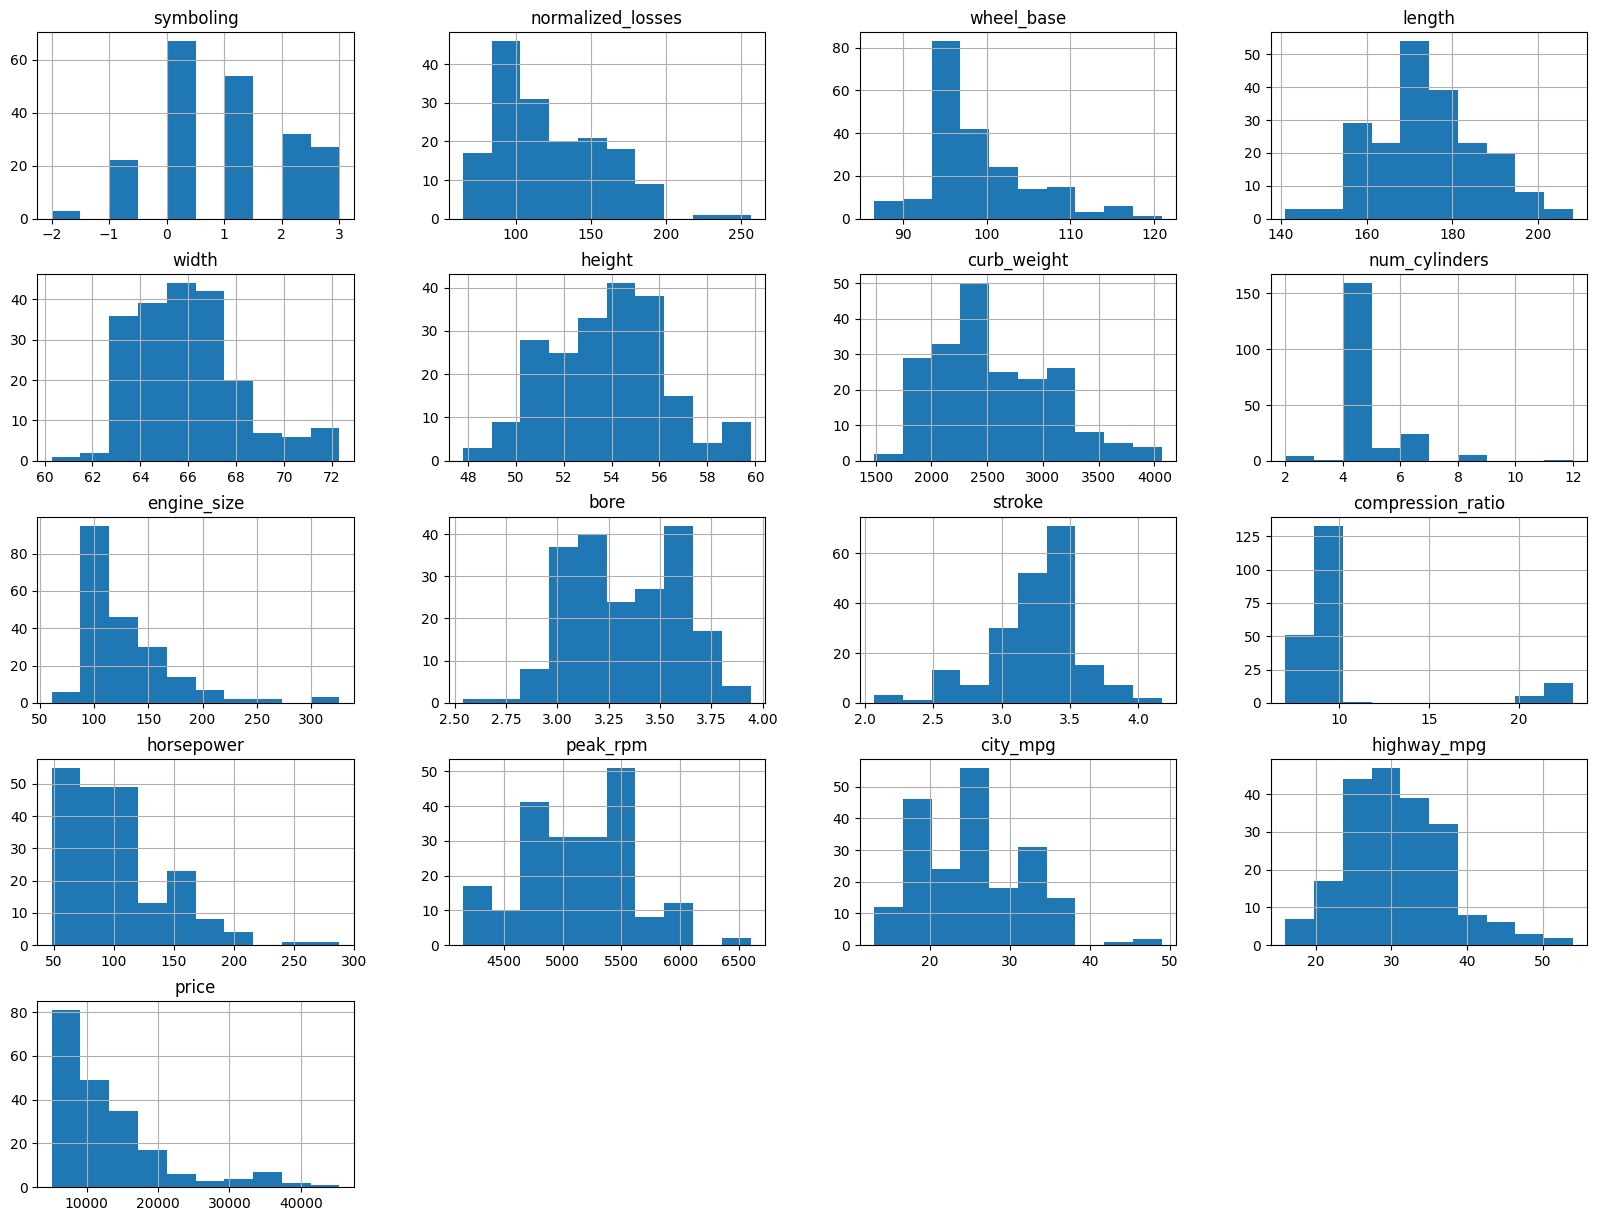

In [ ]:
num_cols.hist(figsize=(20,15))
plt.show()

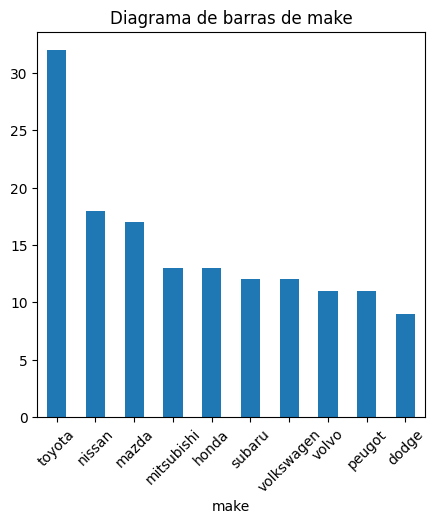

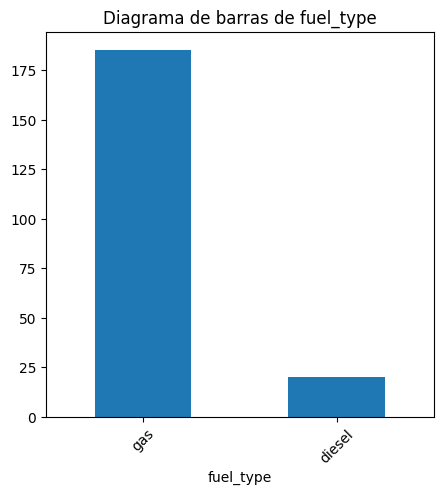

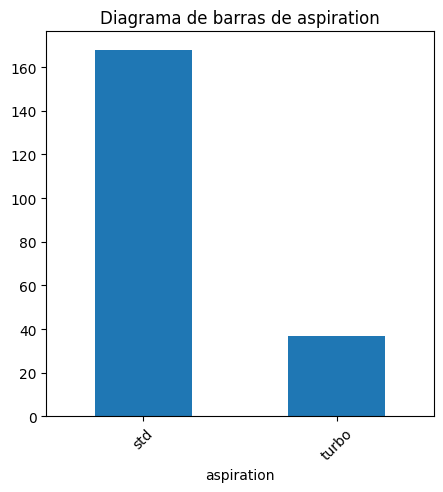

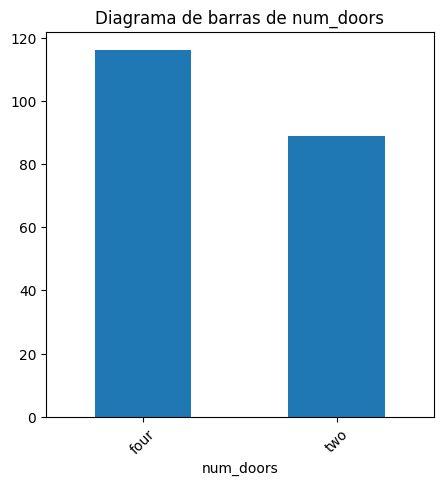

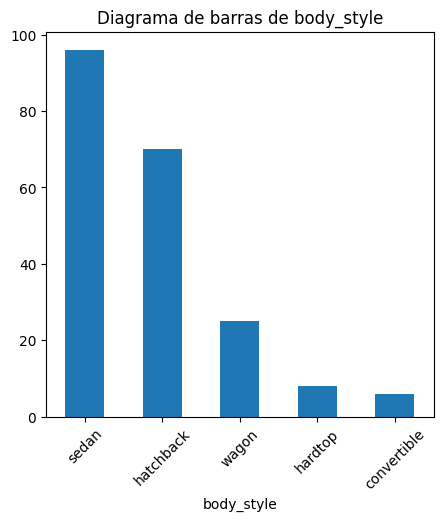

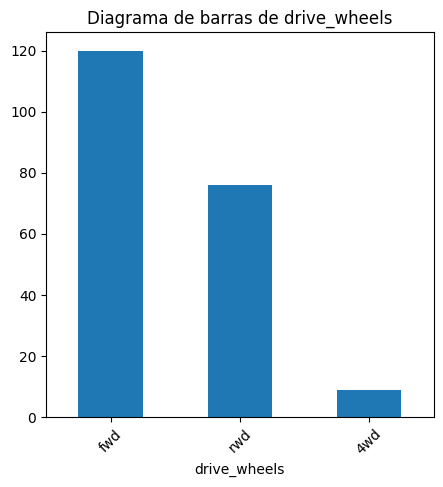

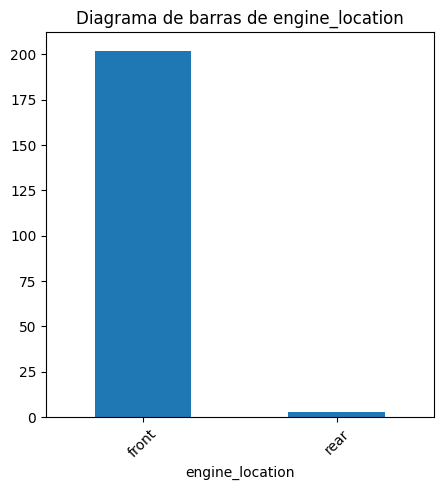

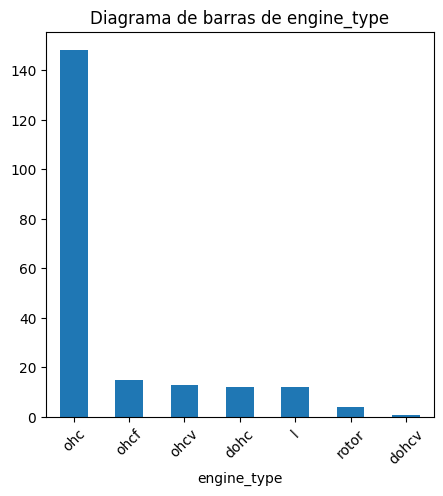

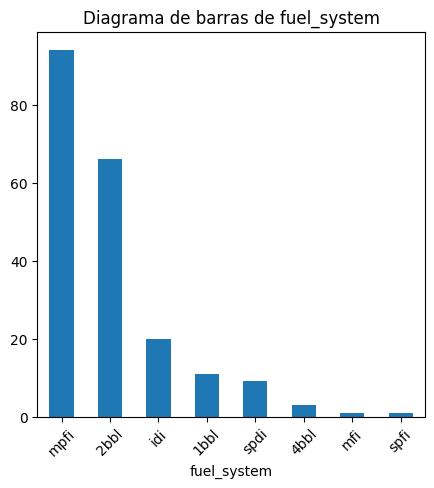

In [ ]:
for col in cat_cols.columns:
    plt.figure(figsize=(5,5))
    cars_df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Bar chart of {col}")
    plt.xticks(rotation=45)
    plt.show()

---

## 3. Exploratory data analysis (bivariate)

**Goals.** Build bivariate charts to get familiar with the dataset, each followed by a conclusion:
- Stacked bars showing the distribution of drive-wheel types for each manufacturer.
- Boxplot of price by body style.
- The 10 most expensive cars, colored by manufacturer.
- Scatter plot of engine size vs. price, colored by aspiration type and sized by number of doors.

### 3.1 Drive-wheel types by manufacturer

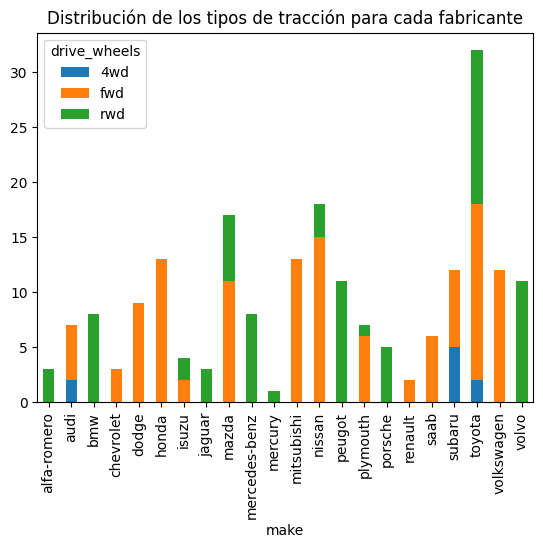

In [ ]:
cars_df.groupby(['make', 'drive_wheels']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Drive-wheel types by manufacturer")
plt.show()

**Conclusion.** Toyota is the make with the most records (32 of 205). Front-wheel drive (`fwd`) is the most common overall (120 of 205 cars), but it does not dominate every make: Alfa Romeo, BMW, Jaguar, Mercedes-Benz, Mercury, Peugeot, Porsche and Volvo only have rear-wheel-drive (`rwd`) cars. Four-wheel drive (`4wd`) is the least common and appears only in Audi, Subaru and Toyota.

### 3.2 Price by body style

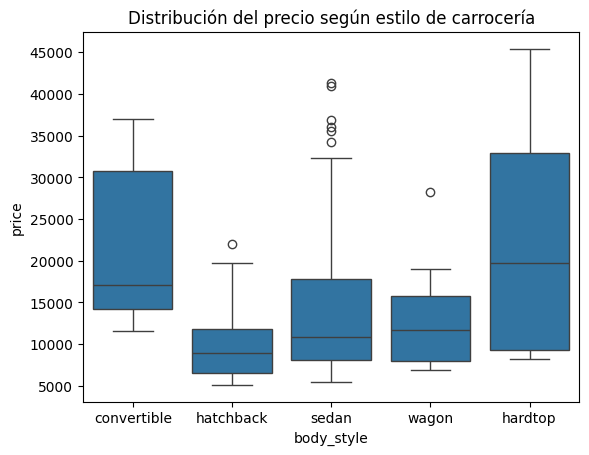

In [ ]:
sns.boxplot(x='body_style', y='price', data=cars_df)
plt.title("Price distribution by body style")
plt.show()

**Conclusion.** The boxplot shows notable price differences between body styles:

- **Hardtop:** the highest median (close to \$20,000) and a wide spread, suggesting high variability within its segment.
- **Convertible:** also a high median (close to \$17,000) with a wide interquartile range, indicating a heterogeneous price market.
- **Sedan:** median close to \$11,000, with an extended upper whisker and several high-price outliers, pointing to luxury versions within the same category.
- **Wagon:** a median similar to the sedan's, but with more concentrated prices and a single outlier.
- **Hatchback:** the most affordable body style, with the lowest median (close to \$9,000), tightly concentrated prices and one isolated upper outlier.

### 3.3 The 10 most expensive cars

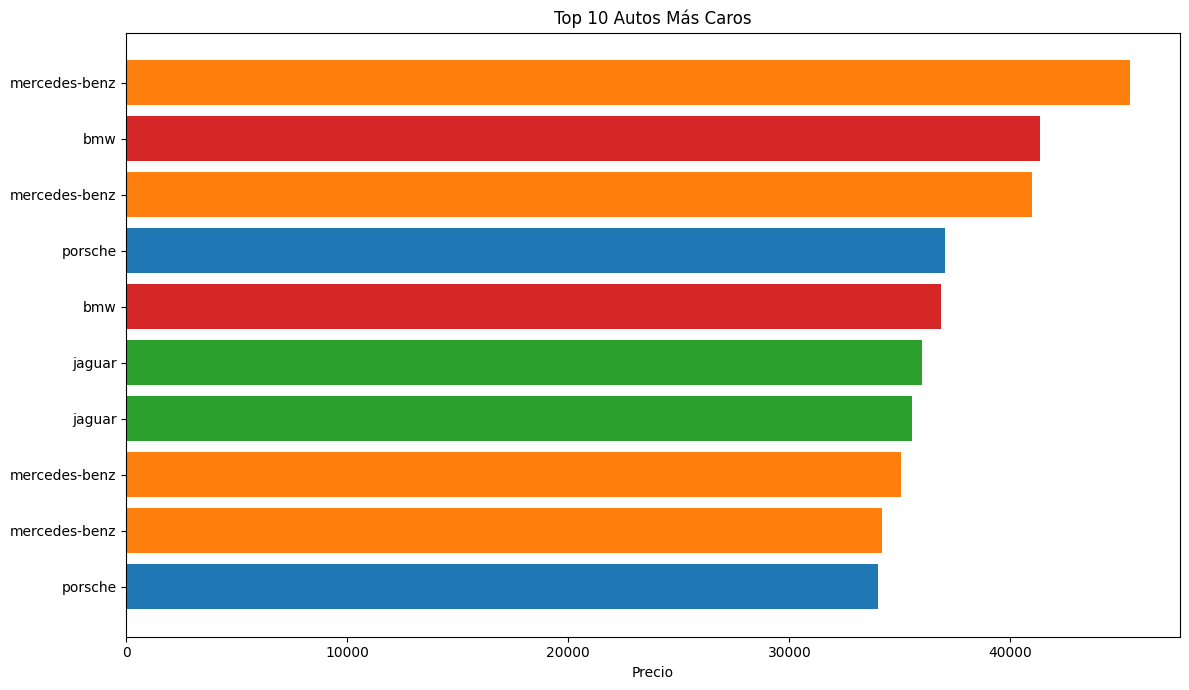

In [ ]:
top10 = cars_df.nlargest(10, 'price').sort_values('price', ascending=True)

manufacturers = top10['make'].unique()
color_map = {maker: plt.cm.tab10.colors[i] for i, maker in enumerate(manufacturers)}

plt.figure(figsize=(12, 7))
plt.barh(range(len(top10)), top10['price'], color=[color_map[f] for f in top10['make']])
plt.yticks(range(len(top10)), top10['make'])
plt.title('Top 10 Most Expensive Cars')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

**Conclusion.** The most expensive cars belong to Mercedes-Benz, BMW, Porsche and Jaguar. Mercedes-Benz has the largest presence in the top 10 (4 of 10 cars); BMW, Porsche and Jaguar contribute 2 each.

### 3.4 Engine size and price

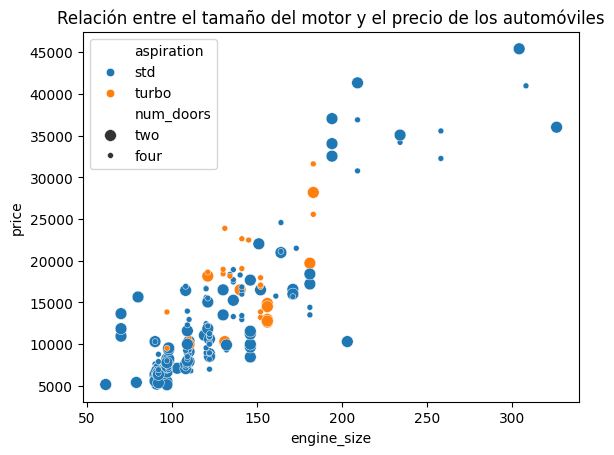

In [ ]:
sns.scatterplot(x='engine_size', y='price', data=cars_df, hue='aspiration', size='num_doors')
plt.title("Engine size vs. price")
plt.show()

**Conclusion.** At first glance, engine size has a positive relationship with price: as `engine_size` increases, prices tend to be higher. Regarding aspiration, turbo cars cluster in mid-range prices, while the highest prices mostly correspond to standard-aspiration (`std`) engines. For the number of doors there is no clear pattern: two- and four-door cars are spread similarly across all price ranges, suggesting this variable has no significant influence on price.

---

## 4. Correlation analysis

**Goals**
- Draw a heatmap of the correlation matrix of the numeric variables, showing the value in each cell.
- Identify the three variables most correlated with price.

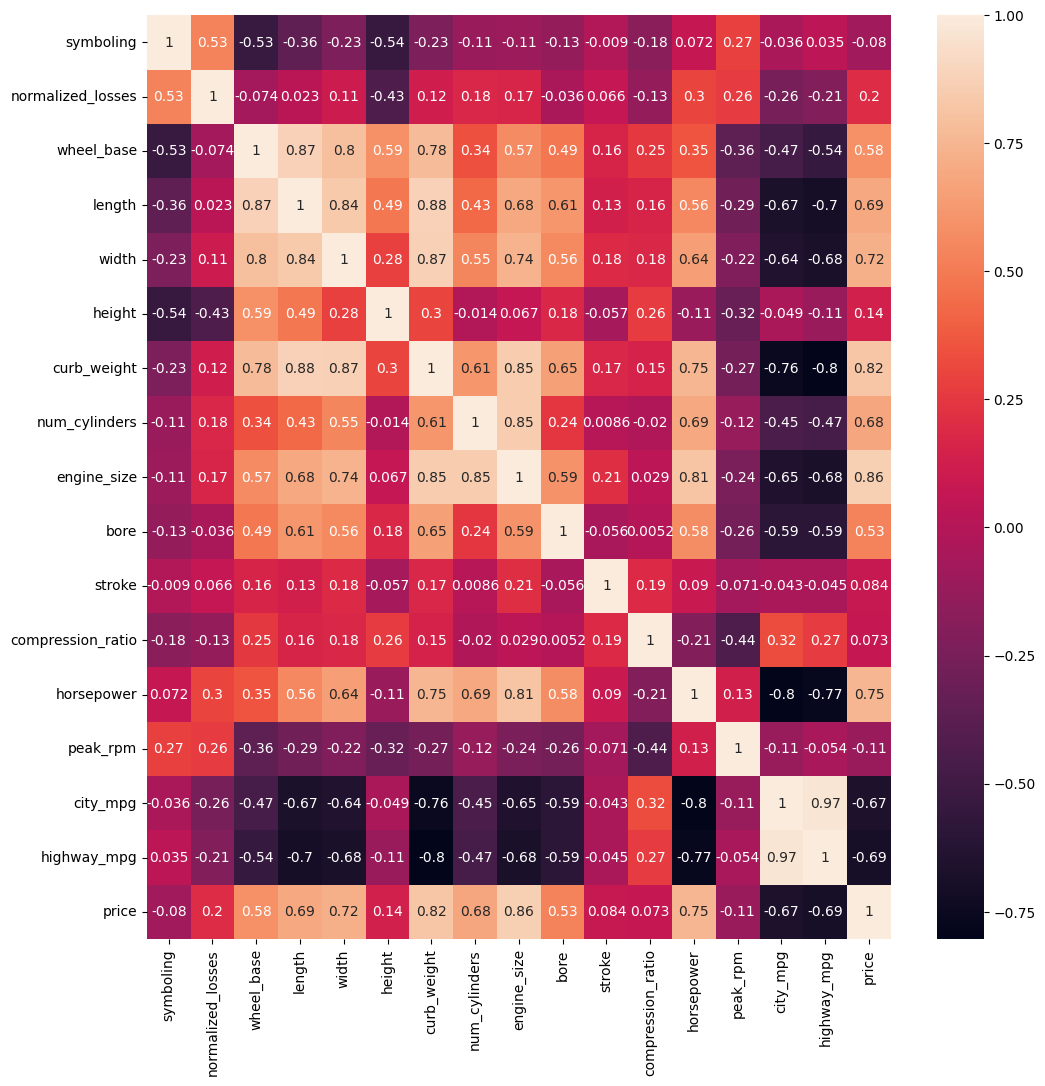

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(num_cols.corr(), annot=True)
plt.show()

**Result.** The three variables most correlated with `price` are:

1. `engine_size` (0.86)
2. `curb_weight` (0.82)
3. `horsepower` (0.75)

A larger engine tends to increase both the vehicle's weight and its power, which suggests that the three largely capture the same phenomenon.

There are also many highly correlated pairs of variables, which can hurt the performance of regression models. PCA is useful not only for reducing dimensionality, but also because principal components are orthogonal to each other (zero correlation), which avoids multicollinearity problems. This is verified below.

---

## 5. Feature engineering

**Goals**
- Separate `price` as the target variable (`y`) and the numeric predictors into `x`. How many principal components will PCA generate?
- Apply `SimpleImputer` to `x` to handle missing values, justifying the strategy.
- Scale the imputed `x` so that all variables contribute equally and none dominates the analysis because of a larger scale.

PCA is designed for numeric variables: it finds linear combinations of the original variables that capture the most variance in the data. That is why the categorical variables are set aside before applying it and concatenated back with the results at the end.

In [ ]:
y = cars_df['price']
x = cars_df.select_dtypes(include='number').drop('price', axis=1)

In [ ]:
total_components = x.shape[1]
total_components

16

**Result.** PCA generates as many components as input variables: 16 in this case.

In [ ]:
imputer = SimpleImputer(strategy='mean')
x_imputed = imputer.fit_transform(x)

**Imputation strategy: mean.** The variables with missing values are `normalized_losses`, `bore`, `stroke`, `horsepower` and `peak_rpm`. Except for `normalized_losses` (20 %), all have under 2 % missing, so the chosen strategy has a minimal effect on them. In terms of skewness, `bore` and `peak_rpm` are nearly symmetric (0.02 and 0.07), `normalized_losses` and `stroke` are moderately skewed (0.77 and −0.68), and only `horsepower` is clearly skewed (1.39), but it has just 2 missing values; this supports using the mean.

Variables such as `num_cylinders` (skewness 2.82) and `compression_ratio` (2.61) do show considerable skew, but they have no missing values, so they do not affect this decision. The median would be the more robust alternative for `horsepower` (skewness 1.39) and `normalized_losses`.

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_imputed)

---

## 6. PCA projection

**Goals**
- Apply `PCA` to the scaled data and project it into the new vector space.
- Name the components PC1, PC2, PC3, and so on.
- Draw a heatmap of the correlation matrix of the components to verify they are uncorrelated.

In [ ]:
pca = PCA()
x_projected = pca.fit_transform(x_scaled)

n_components = x_projected.shape[1]
pc_names = [f'PC{i+1}' for i in range(n_components)]

x_projected = pd.DataFrame(x_projected, columns=pc_names)
x_projected.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.910729,-2.462872,-0.366249,1.354201,-1.913037,1.054132,0.297881,0.249144,-1.049663,-0.379634,-0.444005,0.306443,-0.254595,0.367437,0.188519,0.006380
1,-0.910729,-2.462872,-0.366249,1.354201,-1.913037,1.054132,0.297881,0.249144,-1.049663,-0.379634,-0.444005,0.306443,-0.254595,0.367437,0.188519,0.006380
2,0.641050,-1.420953,0.927080,0.917757,1.831419,-0.758156,-0.607551,1.287471,-1.129892,-1.025200,0.530604,0.633345,0.227962,-0.017152,0.125137,-0.104010
3,-0.341011,-0.915886,0.435219,-1.461309,-0.243596,-0.817464,-0.039104,0.390489,0.280815,0.172466,0.040488,-0.024164,-0.093688,-0.387494,0.008646,0.053461
4,1.194387,-1.776152,0.157809,-1.049408,0.162319,-0.853585,-0.398916,0.854138,-0.016743,-0.435041,-0.068164,-0.412769,-0.072056,0.082292,-0.199885,0.041990


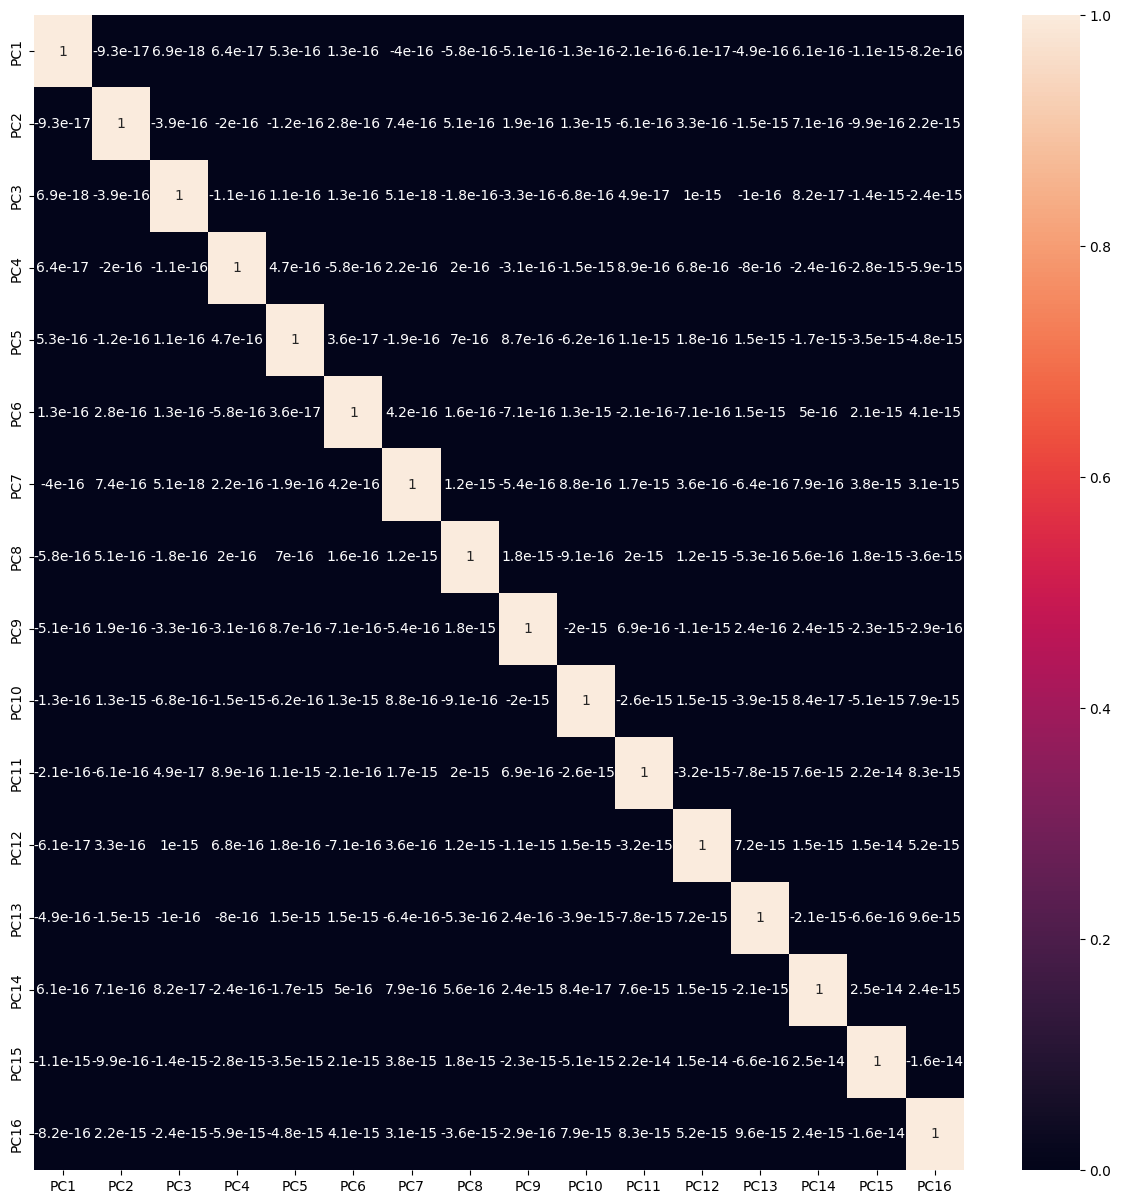

In [ ]:
x_projected_corr = x_projected.corr()
plt.figure(figsize=(15,15))
sns.heatmap(x_projected_corr, annot=True)
plt.show()

**Result.** The principal components are uncorrelated with each other: off the diagonal, the correlations are practically zero. This follows from their orthogonality. Note that being uncorrelated does not imply being statistically independent: it only rules out linear dependence.

---

## 7. Explained variance

**Goals**
- Obtain the percentage of variance explained by each component.
- Plot the cumulative variance curve to find the minimum number of components that explain more than 90 % of the total variance.

In [ ]:
print("Eigenvalues of the covariance matrix of the car data:", [float(v) for v in np.round(pca.explained_variance_, decimals=5)])

Eigenvalues of the covariance matrix of the car data: [7.16737, 2.89837, 1.38891, 1.02059, 0.92049, 0.76417, 0.52112, 0.43436, 0.31088, 0.24944, 0.11953, 0.10127, 0.08138, 0.05659, 0.02495, 0.01898]


In [ ]:
for i in range(0, total_components):
  print(f"The percentage of variance explained by principal component {i+1} is {pca.explained_variance_ratio_[i]*100:.0f} %")

The percentage of variance explained by principal component 1 is 45 %
The percentage of variance explained by principal component 2 is 18 %
The percentage of variance explained by principal component 3 is 9 %
The percentage of variance explained by principal component 4 is 6 %
The percentage of variance explained by principal component 5 is 6 %
The percentage of variance explained by principal component 6 is 5 %
The percentage of variance explained by principal component 7 is 3 %
The percentage of variance explained by principal component 8 is 3 %
The percentage of variance explained by principal component 9 is 2 %
The percentage of variance explained by principal component 10 is 2 %
The percentage of variance explained by principal component 11 is 1 %
The percentage of variance explained by principal component 12 is 1 %
The percentage of variance explained by principal component 13 is 1 %
The percentage of variance explained by principal component 14 is 0 %
The percentage of variance 

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.44577575, 0.62604052, 0.71242421, 0.77589995, 0.83314993,
       0.88067775, 0.91308881, 0.9401036 , 0.95943912, 0.97495293,
       0.98238732, 0.98868611, 0.99374757, 0.99726749, 0.99881926,
       1.        ])

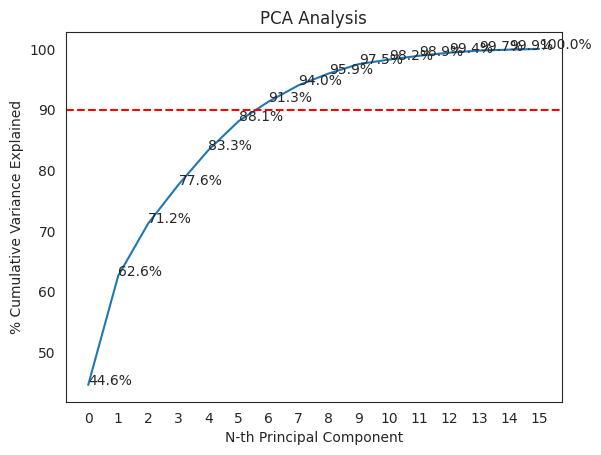

In [ ]:
sns.set_style('white')

plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.title('PCA Analysis')
plt.xlabel('N-th Principal Component')
plt.ylabel('% Cumulative Variance Explained')
plt.axhline(y=90, color='r', linestyle='--')
plt.xticks(np.arange(0,total_components,1))

labels = np.cumsum(pca.explained_variance_ratio_)*100
for i in range(total_components):
  plt.text(i,labels[i],str(format(labels[i],'.1f'))+'%')

**Result.** 7 components explain 91.3 % of the total variance, so 7 components are kept.

---

## 8. Component loadings

**Goals**
- Print the loadings (weights) of the original variables on the selected components to interpret which variables contribute most to each one.
- Draw a bar chart of the variables that contribute most to the first component (PC1).

In [ ]:
num_components = 7
pc_df = pd.DataFrame(abs(pca.components_[:num_components]), columns = x.columns, index=['PC{}'.format(i) for i in range(1, num_components + 1)])
pc_df.T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
symboling,0.095818,0.404121,0.260707,0.078548,0.379146,0.144214,0.091447
normalized_losses,0.030606,0.338734,0.312286,0.319166,0.349229,0.497065,0.321321
wheel_base,0.297125,0.266442,0.030437,0.223240,0.001045,0.187928,0.108482
length,0.337239,0.140940,0.045336,0.190461,0.074600,0.091893,0.018570
width,0.334068,0.057700,0.104657,0.094902,0.014876,0.108939,0.140694
height,0.112466,0.422562,0.278123,0.179867,0.011636,0.225324,0.032545
curb_weight,0.361858,0.024816,0.077773,0.023715,0.042661,0.016433,0.059191
num_cylinders,0.245235,0.113073,0.180834,0.556545,0.263262,0.327502,0.067235
engine_size,0.330215,0.079850,0.199084,0.294453,0.116259,0.031511,0.065229
bore,0.262262,0.004136,0.141388,0.040251,0.389296,0.503709,0.153280


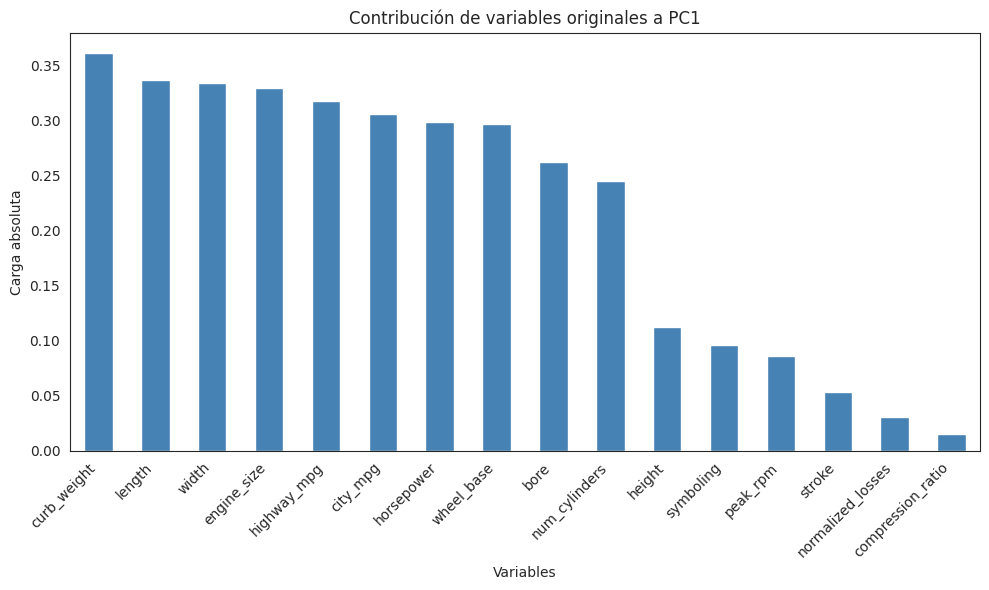

In [ ]:
plt.figure(figsize=(10, 6))
pc_df.loc['PC1'].sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Contribution of original variables to PC1')
plt.xlabel('Variables')
plt.ylabel('Absolute loading')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## 9. Encoding categorical variables

The categorical variables are encoded with one-hot encoding, using `drop='first'` to avoid multicollinearity among the generated dummy variables.

In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(cat_cols)
cat_encoded = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(cat_cols.columns))
cat_encoded.head()

,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


---

## 10. Final dataset

The values projected onto the 7 selected components, the encoded categorical variables and the output variable (`price`) are combined into one dataframe, which is saved as `cars_pca.csv`.

In [ ]:
pca = PCA(n_components=num_components)
x_projected = pca.fit_transform(x_scaled)
x_projected = pd.DataFrame(x_projected, columns=[f'PC{i+1}' for i in range(num_components)])

In [ ]:
final_df = pd.concat([x_projected, cat_encoded, y], axis=1)
final_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.910729,-2.462872,-0.366249,1.354201,-1.913037,1.054132,0.297881,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13495
1,-0.910729,-2.462872,-0.366249,1.354201,-1.913037,1.054132,0.297881,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500
2,0.641050,-1.420953,0.927080,0.917757,1.831419,-0.758156,-0.607551,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500
3,-0.341011,-0.915886,0.435219,-1.461309,-0.243596,-0.817464,-0.039104,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13950
4,1.194387,-1.776152,0.157809,-1.049408,0.162319,-0.853585,-0.398916,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17450


In [ ]:
final_df.to_csv('cars_pca.csv', index=False)

---

## 11. Notes and next steps

- **Data leakage.** The imputer, the scaler and PCA are fitted on the full dataset before any train/test split. To evaluate a model, split first and fit these transformations on the training data only (e.g., inside a `Pipeline`).
- **Sample size.** With 205 records, the results (especially the variance percentages and the loadings) can change considerably with a different sample; cross-validation is advisable.
- **Drive-wheel chart.** It shows counts, not proportions. A normalized version (dividing each row of the table by its sum, with `table.div(table.sum(axis=1), axis=0)`, before plotting) lets you compare each make's composition without being dominated by its number of records.
- **Absolute loadings.** The loadings table uses `abs()`, which shows the magnitude of each contribution but hides its sign; inspect the signed loadings to interpret the direction of each component.
- **`symboling`.** It is an ordinal risk scale (−3 to +3) treated here as numeric; that is reasonable, but worth keeping in mind when interpreting the components.

---

## AI usage statement

- Anthropic. (2026). *Claude* (claude-sonnet-5-5) [Large language model]. Used to restructure and format the notebook documentation, correct typos, and translate it into English.